In this notebook we plot the mean and standard deviation of the PnL of our portfolio (where we long one letf and short one underlying), for varying leverage factors and durations.

We begin with mean value:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import simulate_gbm

In [2]:
def mean_diff(S0, mu, sigma, T, N, n_paths, leverage):
    return simulate_gbm(S0, mu, sigma, T, int(N), n_paths, leverage).mean()


def plot_heat_leverage_duration(
    mu=0,
    sigma=0.02,
    Ts=np.linspace(1, 200, 200),
    freq=1,
    n_paths=1000,
    factors=np.linspace(1, 5, 100),
):
    T, factor = np.meshgrid(Ts, factors)

    diff = np.vectorize(mean_diff)(1, mu, sigma, T, T * freq, n_paths, factor)

    plt.figure()
    plt.contourf(T, factor, diff, cmap="coolwarm")
    plt.title("Average percentage difference lETF - underlying")
    plt.xlabel("Duration (days)")
    plt.ylabel("Leverage factor")
    plt.colorbar()

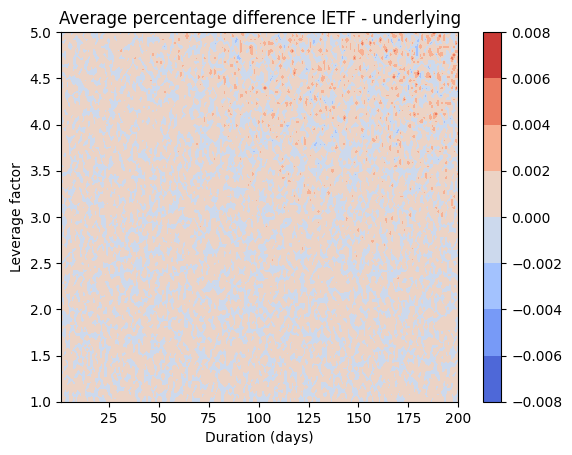

In [3]:
plot_heat_leverage_duration()

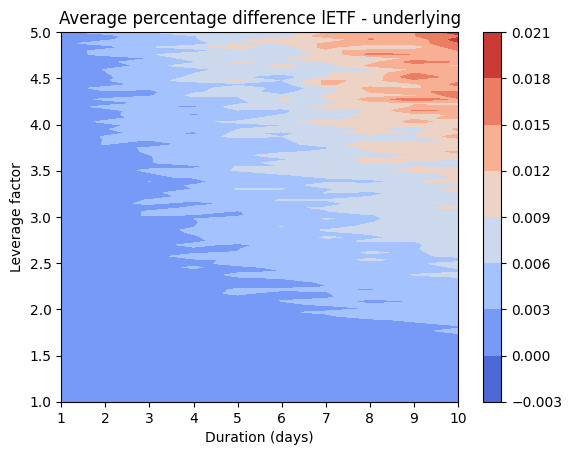

In [4]:
plot_heat_leverage_duration(mu=0.1, Ts=np.linspace(1, 10, 10), sigma=0.1)

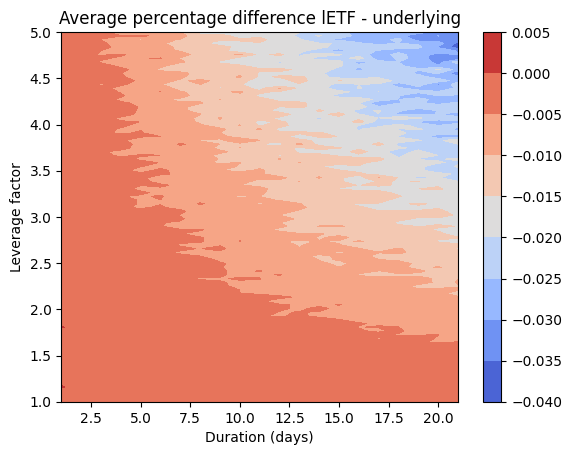

In [5]:
plot_heat_leverage_duration(mu=-0.1, Ts=np.linspace(1, 21, 21), sigma=0.1)

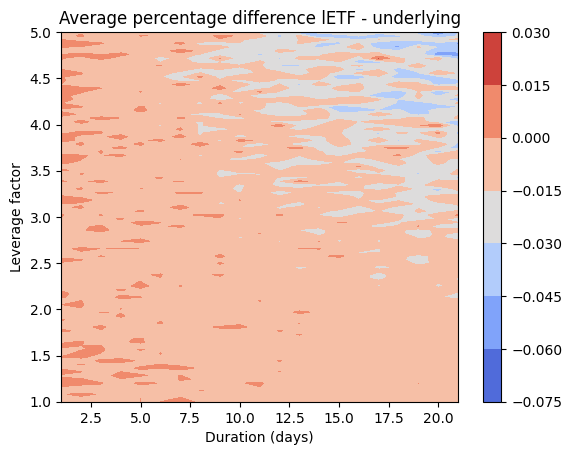

In [6]:
plot_heat_leverage_duration(mu=-0.1, Ts=np.linspace(1, 21, 21), sigma=0.4)

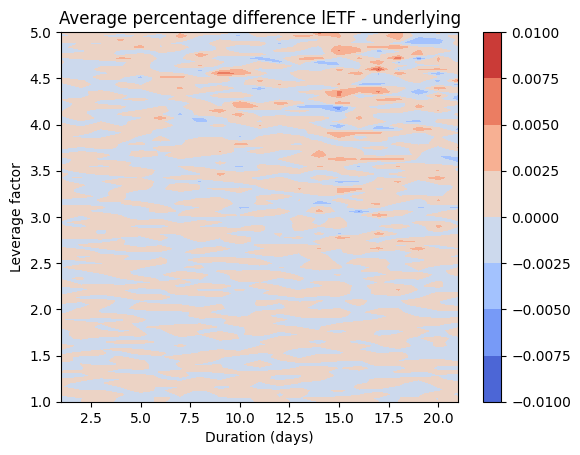

In [7]:
plot_heat_leverage_duration(mu=0, Ts=np.linspace(1, 21, 21), sigma=0.1)

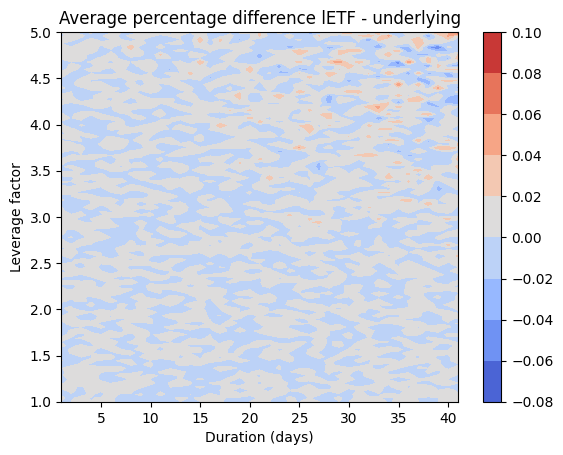

In [8]:
plot_heat_leverage_duration(mu=0, Ts=np.linspace(1, 41, 41), sigma=0.4)

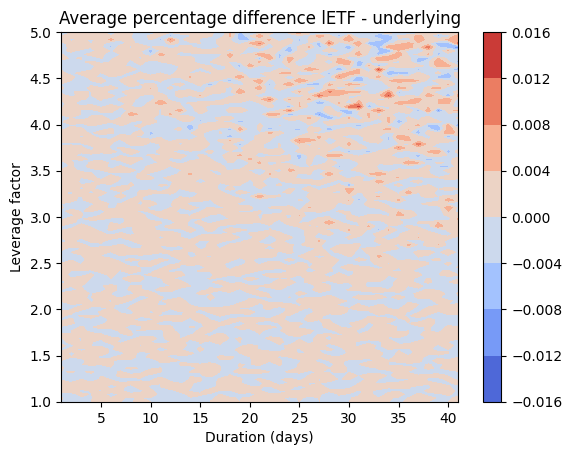

In [9]:
plot_heat_leverage_duration(mu=0, Ts=np.linspace(1, 41, 41), sigma=0.1)

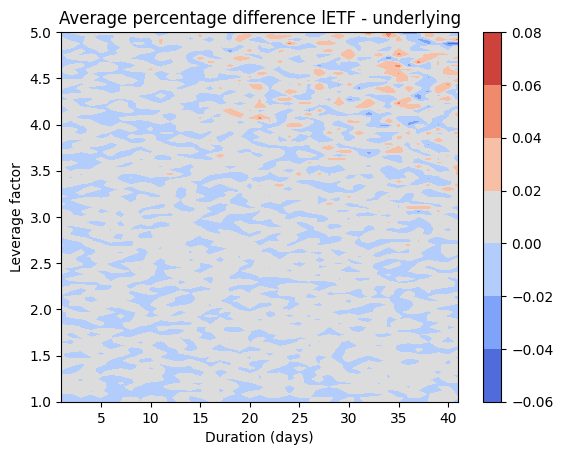

In [10]:
plot_heat_leverage_duration(mu=0.01, Ts=np.linspace(1, 41, 41), sigma=0.4)

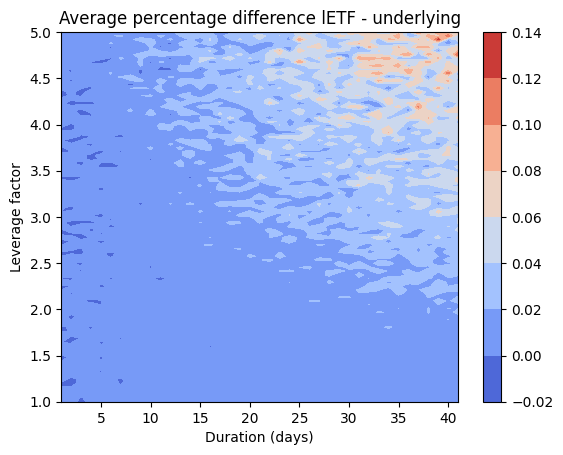

In [11]:
plot_heat_leverage_duration(mu=0.1, Ts=np.linspace(1, 41, 41), sigma=0.4)

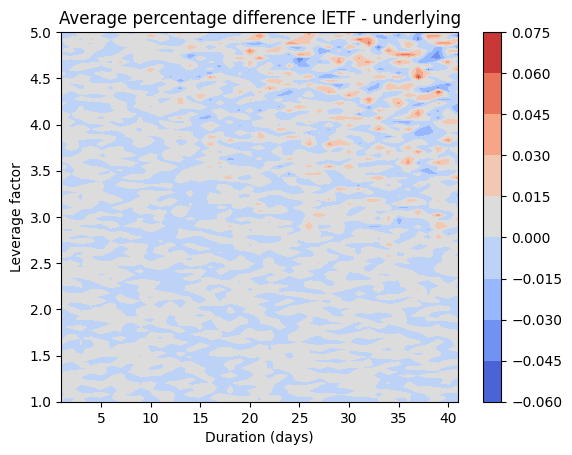

In [12]:
plot_heat_leverage_duration(mu=0, Ts=np.linspace(1, 41, 41), sigma=0.4)

We now turn to standard deviation of PnL:

In [13]:
def std_diff(S0, mu, sigma, T, N, n_paths, leverage):
    return simulate_gbm(S0, mu, sigma, T, int(N), n_paths, leverage).std()

In [14]:
def plot_heat_leverage_duration_std(
    mu=0,
    sigma=0.02,
    Ts=np.linspace(1, 200, 200),
    freq=1,
    n_paths=1000,
    factors=np.linspace(2, 5, 100),
):
    T, factor = np.meshgrid(Ts, factors)

    diff = np.log(np.vectorize(std_diff)(1, mu, sigma, T, T * freq, n_paths, factor))

    plt.figure(figsize = (4,3))
    plt.contourf(T, factor, diff, cmap="coolwarm")
    plt.title("Average percentage difference lETF - underlying")
    plt.xlabel("Duration (days)")
    plt.ylabel("Leverage factor")
    plt.colorbar()

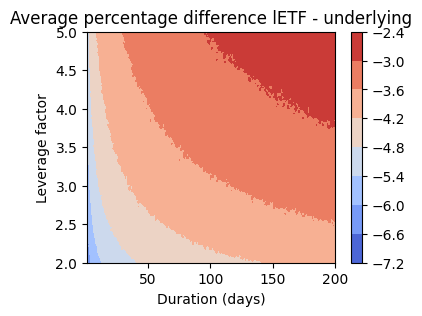

In [15]:
plot_heat_leverage_duration_std()

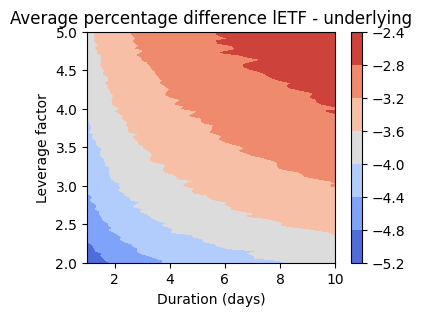

In [16]:
plot_heat_leverage_duration_std(mu=0.1, Ts=np.linspace(1, 10, 10), sigma=0.1)

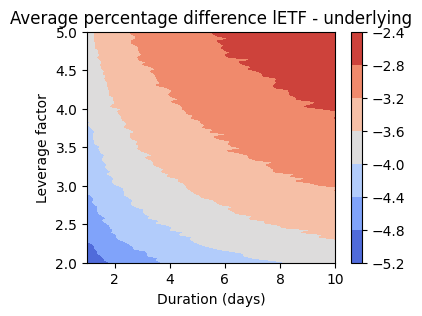

In [17]:
plot_heat_leverage_duration_std(mu=0.3, Ts=np.linspace(1, 10, 10), sigma=0.1)

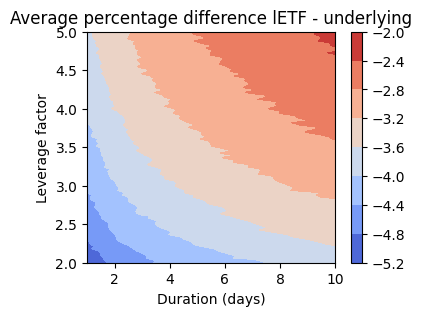

In [18]:
plot_heat_leverage_duration_std(mu=0.9, Ts=np.linspace(1, 10, 10), sigma=0.1)

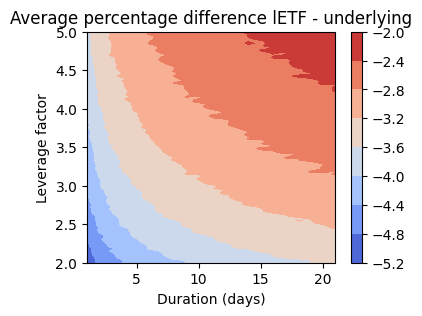

In [19]:
plot_heat_leverage_duration_std(mu=-0.1, Ts=np.linspace(1, 21, 21), sigma=0.1)

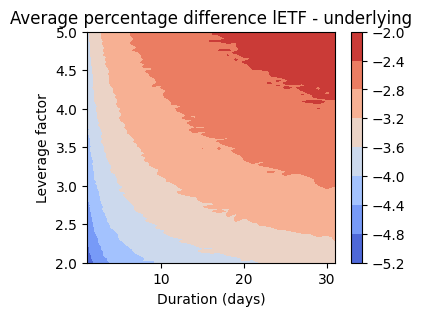

In [20]:
plot_heat_leverage_duration_std(mu=-0.3, Ts=np.linspace(1, 31, 31), sigma=0.1)

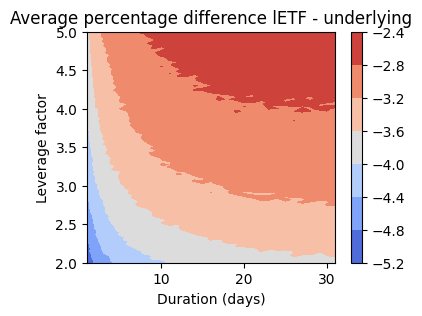

In [21]:
plot_heat_leverage_duration_std(mu=-0.9, Ts=np.linspace(1, 31, 31), sigma=0.1)

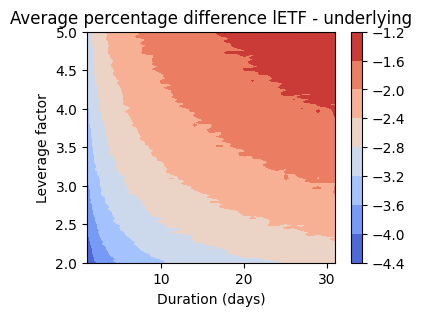

In [22]:
plot_heat_leverage_duration_std(mu=-0.1, Ts=np.linspace(1, 31, 31), sigma=0.2)

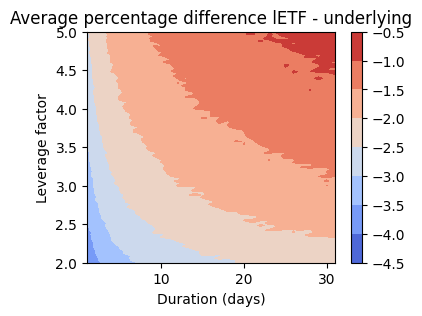

In [23]:
plot_heat_leverage_duration_std(mu=-0.1, Ts=np.linspace(1, 31, 31), sigma=0.3)

There is a much clearer signal relating duration and leverage factor to standard deviation than to mean, so we are inclined to focus our investigation on standard deviation.